In [1]:
using Clapeyron, Metaheuristics, Printf

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
propanol,60.096,2.7801,3.3333,231.77,1,1
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,propanol,-0.01
"""

assoc_parameter = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2424.4,0.017505
co2,H,co2,e,0,0
propanol,H,co2,e,1212.2,0
propanol,e,co2,H,1212.2,0
"""

model = PCSAFT(["co2", "propanol"], userlocations = [like_parameter, unlike_parameter, assoc_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 200.2986900384773; 200.2986900384773 231.77]
[2.785e-10 3.05915e-10; 3.05915e-10 3.3333000000000003e-10]
kij = -0.010000000000000009


In [3]:
function vle_p(model::EoSModel, x_co2::Float64)
    T = 313.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return p
end

function vle_y(model::EoSModel, x_co2::Float64)
    T = 313.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return y
end

vle_y (generic function with 1 method)

In [4]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 10.0,
        :upper   => 800.0,
        :guess   => 201.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 800.0, :param => :epsilon, :indices => (1, 2), :guess => 201.0, :lower => 10.0)

In [5]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vlep_propanol.csv")
fix_line_endings("vley_propanol.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vlep_propanol.csv"
        "vley_propanol.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vlep_propanol.csv
Fixed: vley_propanol.csv
Initial objective value: 1.0e100


In [6]:
method = ECA(; options = Options(iterations = 10000, seed = 999))
 
params_opt, model_opt = optimize(objective, estimator, method)

([201.0], PCSAFT{BasicIdeal, Float64}("co2", "propanol"))

In [7]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 201.0; 201.0 231.77]
[2.785e-10 3.05915e-10; 3.05915e-10 3.3333000000000003e-10]
kij = -0.013536333967046232


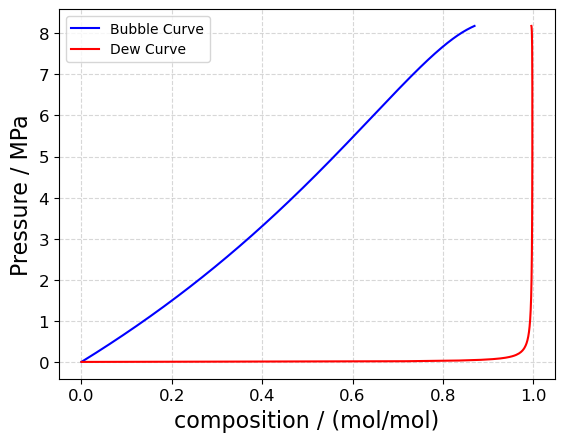

In [8]:
import PyPlot; const plt = PyPlot
using Clapeyron
"""
N = 300
T = 313.15

# 1. Menaikkan rentang batas atas X sedikit (misal ke 0.95 atau 0.98) 
# agar kurva puncak kritisnya bisa terhitung dan menutup sempurna.
x = range(1e-8, 1, length=N)

p = zeros(N)
y = zeros(N)

# Inisialisasi variabel v0 untuk menampung tebakan awal secara kontinu
v0 = []

# 2. Perulangan dengan proteksi try-catch
for j in 1:N
    try
        if j == 1
            # Iterasi pertama menggunakan tebakan default Clapeyron
            bub = bubble_pressure(model_opt, T, [x[j], 1-x[j]])
            p[j] = bub[1]
            y[j] = bub[4][1]
            
            # Simpan tebakan awal untuk iterasi berikutnya
            v0 = [log10(bub[2]), log10(bub[3]), bub[4][1], bub[4][2]]
        else
            # Iterasi selanjutnya memanfaatkan nilai v0 dari titik sebelumnya
            bub = bubble_pressure(model_opt, T, [x[j], 1-x[j]]; v0=v0)
            p[j] = bub[1]
            y[j] = bub[4][1]
            
            # Perbarui nilai v0 dengan hasil konvergensi terbaru
            v0 = [log10(bub[2]), log10(bub[3]), bub[4][1], bub[4][2]]
        end
    catch e
        # JIKA solver gagal konvergen di dekat titik kritis, titik tersebut 
        # akan diisi dengan NaN (Not a Number) agar kode TIDAK crash/eror,
        # dan grafik Python tetap bisa menggambar bagian yang sukses.
        p[j] = NaN
        y[j] = NaN
    end
end
"""
N    = 401
idxend = N
T    = 313.15

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    if i==1
        bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
        p[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(log10.([bub[2],bub[3]]),[x[i+1],1-x[i+1]])
    else
        bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]]; v0 = v0)
        p[i] = bub[1]
        y[i] = bub[4][1]
        v0   = vcat(log10.([bub[2],bub[3]]),bub[4])
        if abs(y[i] - x[i])/x[i] < 1e-3
            idxend = i
            break
        end
    end
end

# 3. Bagian pembuatan grafik (Plotting)
plt.clf()
plt.plot(x, p./1e6, color="blue", label="Bubble Curve")
plt.plot(y, p./1e6, color="red", label="Dew Curve")
plt.xlabel("composition / (mol/mol)", fontsize=16)
plt.ylabel("Pressure / MPa", fontsize=16)
plt.xlim()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.grid(true, linestyle="--", alpha=0.5) # opsional: menambahkan grid tipis agar rapi

In [9]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [10]:
aard_p   = calculate_AAD(model_opt, "vlep_propanol.csv", vle_p)


=== AAD: vlep_propanol.csv ===

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



Clapeyron Estimator  exp           calc          ARD%    
0.0881      1410000.000000  628634.683784  55.4160 
0.1526      2370000.000000  1118047.311451  52.8250 
0.1904      2920000.000000  1419365.977093  51.3916 
0.2571      3740000.000000  1978989.900652  47.0858 
0.3342      4600000.000000  2673115.609515  41.8888 
0.4619      5910000.000000  3940718.559409  33.3212 
0.6111      7090000.000000  5594085.192929  21.0989 
0.8453      7980000.000000  8036194.579818  0.7042  
0.9183      8190000.000000  NaN           NaN     
AARD = NaN%


NaN

In [11]:
aard_p   = calculate_AAD(model_opt, "vley_propanol.csv", vle_y)


=== AAD: vley_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


0.0881      0.993900      0.989017      0.4913  
0.1526      0.995400      0.993628      0.1780  
0.1904      0.996000      0.994878      0.1126  
0.2571      0.996300      0.996177      0.0124  
0.3342      0.996300      0.997012      0.0714  
0.4619      0.996000      0.997722      0.1729  
0.6111      0.995100      0.998025      0.2939  
0.8453      0.992100      0.996946      0.4884  
0.9183      0.992000      NaN           NaN     
AARD = NaN%


NaN